# MNIST 

The mnist dataset is a dataset containing 70,000 grayscale images, each representing handwritten digit from 0 to 9. It is the starting point for understanding Computer vision.

For this task. I will use **Tensorflow** to do the heavylifting.

> Tensorflow is a specialised python library from Google that handles the heavy lifting of data loading and neural network construction.

The first step is to import tensorflow and using it download and load the MNIST dataset.

In [1]:
import tensorflow as tf
mnist = tf.keras.datasets.mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

(x_train, y_train),(x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 7s 1us/step


Now we need to understand the shape of our dataset.

In [2]:
print(f"Training images shape: {x_train.shape}")
print(f"Training labels shape: {y_train.shape}")

Training images shape: (60000, 28, 28)
Training labels shape: (60000,)


>60, 000 is the number of images in the set, 28 is the height of each image and the second 28 is the width of each image.

**Preparing the data**

Neural networks usually perform better with the input values are between 0 and 1 rather than 0 and 255. (maximum value of a pixel is 255).

We will use division to scale them down.

In [3]:
x_train = x_train / 255.0
x_test = x_test /255.0

**Visualizing the data**

We will use matplotlib to plot the data and actually see one of the images.


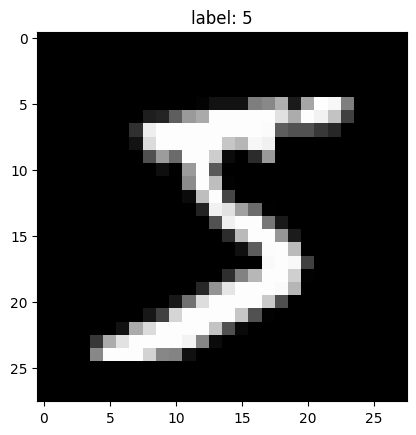

In [4]:
import matplotlib.pyplot as plt

plt.imshow(x_train[0], cmap='gray')
plt.title(f"label: {y_train[0]}")
plt.show()

**Preparing the labels**

To distinguish digits using TensorFlow, we can convert our labels (y_train and y_test) into this one-hot format using a built in utility.

In [5]:
y_train = tf.keras.utils.to_categorical(y_train,10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

print(f"y_train shape has been converted: {y_train[0].shape}")

y_train shape has been converted: (10,)


**Defining the model**

Using Sequential to define the model and dense layers for the neurons

ReLu(Recitified Linear Unit) is the most common "activation function" in AI. it helps the model learn complex patterns by essentially deciding which neurons should "fire".

Softmax: I used this at the end to turn the raw numbers into probabilities.

In [7]:
from tensorflow.keras import layers, models, Input

model = models.Sequential ([
    Input(shape=(28,28)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

**Compiling and Training**

This is a classification task. I need to use an optimizer called ```adam``` .
I will therefore minimize the loss function during training.

In [8]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy', #used for one-Hot labels
    metrics=['accuracy'] #tracking the % correct
)

model.fit(x_train, y_train, epochs=5, batch_size=32)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.9259 - loss: 0.2582
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9654 - loss: 0.1154
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9754 - loss: 0.0793
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9815 - loss: 0.0595
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9861 - loss: 0.0453


The model looks at the entire set of 60,000 images five times. However, instead of looking at one image at a time, it looks at "clumps" of 32 images before updating its internal math.

> The model is officially trained

**Testing**

I need to see if the model actually learned. Using the Test set containing 10,000 images.

In [9]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9755 - loss: 0.0812
Test Accuracy: 97.55%
